Columns in dataset:
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']

Using unemployment column: Estimated Unemployment Rate (%)

UNEMPLOYMENT ANALYSIS RESULTS

Period distribution:
Period
Before COVID    536
During COVID    232
Name: count, dtype: int64

Before COVID Average: 9.51%
During COVID Average: 17.77%
Absolute Increase: 8.26 percentage points
Percentage Increase: 86.9%


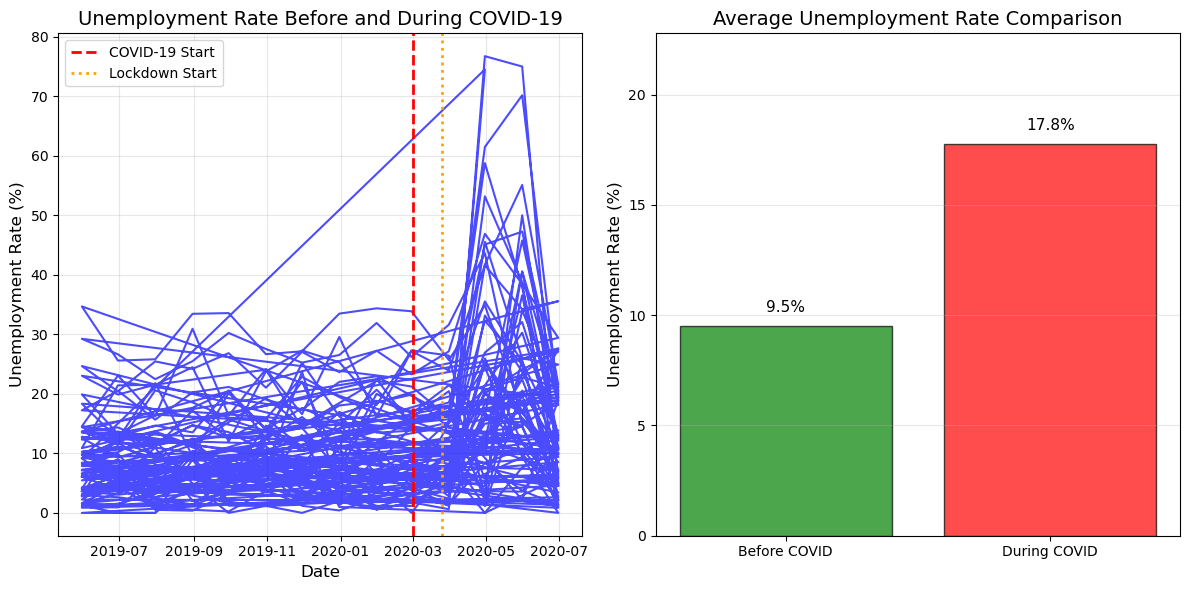

<Figure size 800x600 with 0 Axes>

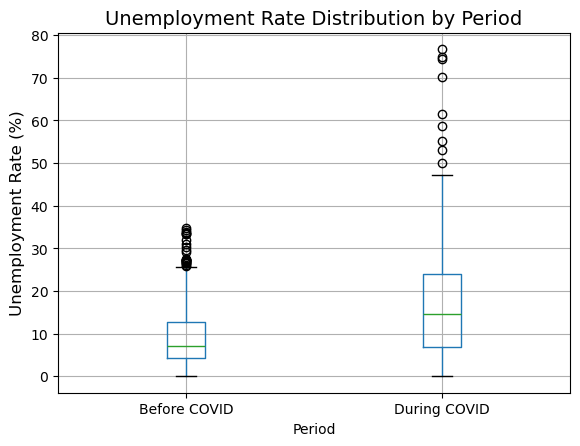


KEY INSIGHTS
• Unemployment rate increased from 9.5% to 17.8%
• That's a 8.3 percentage point increase
• The unemployment rate rose by 86.9% relative to pre-COVID levels
• This shows the significant economic impact of the COVID-19 pandemic


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# STEP 1: LOAD THE DATA
# ============================================
df_main = pd.read_csv(r"C:\Users\khuma\Desktop\OASIS Internship\Unemployment in India.csv")
df_recent = pd.read_csv(r"C:\Users\khuma\Desktop\OASIS Internship\Unemployment_Rate_upto_11_2020.csv")

# Clean column names (remove extra spaces)
df_main.columns = df_main.columns.str.strip()

# Check actual column names to find the unemployment rate column
print("Columns in dataset:")
print(df_main.columns.tolist())

# Find the correct unemployment column name
unemp_col = None
for col in df_main.columns:
    if 'unemployment' in col.lower() or 'rate' in col.lower():
        unemp_col = col
        break

print(f"\nUsing unemployment column: {unemp_col}")

# ============================================
# STEP 2: CONVERT DATE AND ADD PERIOD
# ============================================
df_main['Date'] = pd.to_datetime(df_main['Date'], dayfirst=True)

def determine_period(date):
    if date < pd.Timestamp('2020-03-01'):
        return 'Before COVID'
    else:
        return 'During COVID'

df_main['Period'] = df_main['Date'].apply(determine_period)

# ============================================
# STEP 3: CALCULATE STATISTICS
# ============================================
before_COVID_mean = df_main[df_main['Period'] == 'Before COVID'][unemp_col].mean()
during_COVID_mean = df_main[df_main['Period'] == 'During COVID'][unemp_col].mean()

increase = during_COVID_mean - before_COVID_mean
percentage_increase = (increase / before_COVID_mean) * 100

print("\n" + "="*50)
print("UNEMPLOYMENT ANALYSIS RESULTS")
print("="*50)
print("\nPeriod distribution:")
print(df_main['Period'].value_counts())
print(f"\nBefore COVID Average: {before_COVID_mean:.2f}%")
print(f"During COVID Average: {during_COVID_mean:.2f}%")
print(f"Absolute Increase: {increase:.2f} percentage points")
print(f"Percentage Increase: {percentage_increase:.1f}%")

# ============================================
# STEP 4: VISUALIZATION
# ============================================
plt.figure(figsize=(12, 6))

# Plot 1: Unemployment Rate Over Time
plt.subplot(1, 2, 1)
plt.plot(df_main['Date'], df_main[unemp_col], 'b-', linewidth=1.5, alpha=0.7)
plt.axvline(x=pd.Timestamp('2020-03-01'), color='red', linestyle='--', linewidth=2, label='COVID-19 Start')
plt.axvline(x=pd.Timestamp('2020-03-25'), color='orange', linestyle=':', linewidth=2, label='Lockdown Start')
plt.title('Unemployment Rate Before and During COVID-19', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Unemployment Rate (%)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Bar Chart - Before vs During COVID
plt.subplot(1, 2, 2)
bars = plt.bar(['Before COVID', 'During COVID'], [before_COVID_mean, during_COVID_mean], 
               color=['green', 'red'], alpha=0.7, edgecolor='black')
plt.title('Average Unemployment Rate Comparison', fontsize=14)
plt.ylabel('Unemployment Rate (%)', fontsize=12)
plt.ylim(0, max(before_COVID_mean, during_COVID_mean) + 5)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=11)

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ============================================
# STEP 5: ADDITIONAL INSIGHT - BOX PLOT
# ============================================
plt.figure(figsize=(8, 6))
df_main.boxplot(column=unemp_col, by='Period', grid=True)
plt.title('Unemployment Rate Distribution by Period', fontsize=14)
plt.suptitle('')  # Remove default title
plt.ylabel('Unemployment Rate (%)', fontsize=12)
plt.show()

# ============================================
# STEP 6: SUMMARY INSIGHTS
# ============================================
print("\n" + "="*50)
print("KEY INSIGHTS")
print("="*50)
print(f"• Unemployment rate increased from {before_COVID_mean:.1f}% to {during_COVID_mean:.1f}%")
print(f"• That's a {increase:.1f} percentage point increase")
print(f"• The unemployment rate rose by {percentage_increase:.1f}% relative to pre-COVID levels")
print("• This shows the significant economic impact of the COVID-19 pandemic")